# 🛒 E-Commerce Sales Analysis

## Project Objective

This project aims to uncover actionable insights from historical e-commerce transactions and explore customer and product-level behaviors. In addition to exploratory data analysis (EDA), we extend the analysis with segmentation and product-level patterns to support data-driven business strategies.

### Key Strategic Questions:
- Which product categories and stock codes drive the most revenue?
- Are there temporal patterns in purchasing behavior (hour, day, month)?
- How can customers be segmented based on their purchase behavior?
- What sales strategies can be derived from customer and product trends?
---

## 1. Load & Clean the Dataset

This step establishes the foundation of our analysis. We begin by loading the raw dataset and investigating its structure, completeness, and business logic. Based on data patterns, we apply cleaning strategies that preserve valuable information and ensure analytical integrity.

### 1.1 Load and Preview the Dataset

We import necessary libraries and load the dataset. Initial inspection will give us a high-level understanding of the dataset's shape and structure.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv('../datasets/ecommerce_data.csv', encoding='ISO-8859-1')

# Display basic information
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### 1.2 Investigate Missing and Incomplete Data

We quantify missing values and explore their significance. This helps us form a plan for handling incomplete records.

In [2]:
# Check number of missing values in each column
missing_summary = df.isnull().sum().sort_values(ascending=False)
print("Missing summary:\n")
print(missing_summary)

# Check proportion of missing values
missing_ratio = df.isnull().mean().round(4) * 100
print("\nMissing ratio:\n")
print(missing_ratio.sort_values(ascending=False))

Missing summary:

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

Missing ratio:

CustomerID     24.93
Description     0.27
InvoiceNo       0.00
StockCode       0.00
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
Country         0.00
dtype: float64


In [3]:
# Investigate what kind of products are being purchased without CustomerID
guest_product_stats = (
    df[df['CustomerID'].isnull()]
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
)
print("\nProducts purchased by guest:\n")
print(guest_product_stats.head(10))


Products purchased by guest:

Description
CHARLOTTE BAG SUKI DESIGN          9177
POPCORN HOLDER                     5830
RED RETROSPOT CHARLOTTE BAG        4962
WOODLAND CHARLOTTE BAG             4073
PAPER CHAIN KIT 50'S CHRISTMAS     3738
RABBIT NIGHT LIGHT                 3586
came coded as 20713                3100
PARTY BUNTING                      2995
STRAWBERRY CHARLOTTE BAG           2951
PACK OF 72 RETROSPOT CAKE CASES    2630
Name: Quantity, dtype: int64


- Approximately **25%** of transactions are missing `CustomerID`, indicating guest purchases.
- Only 0.27% of rows have missing `Description`, suggesting low impact but still worth reviewing.
- Products purchased by guests include top-selling items.

### 1.3 Identify Cancellable and Business-Relevant Transactions

We check whether missing descriptions are recoverable using `StockCode`, and validate if 'C'-prefixed invoices signify cancellations.

In [4]:
# Identify StockCodes with missing Description
null_desc_codes = df[df['Description'].isnull()]['StockCode'].value_counts()

# Check if these StockCodes also appear elsewhere with valid descriptions
valid_code_set = set()
for code in null_desc_codes.index:
    descs = df[df['StockCode'] == code]['Description'].dropna().unique()
    if len(descs) >= 3:
        valid_code_set.add(code)
print(valid_code_set)
print("Number of valid codes:", len(valid_code_set))

{'21578', '23268', '35965', '22734', '22812', '22121', '21811', '79030D', '20713', '23091', '85185B', '21830', '22848', '37327', '21147', '21700', '21868', '82494L', '22467', '40016', '82583', '21804', '72817', '23084', '84406B', '37370', '21937', '21621', '84944', '22719', '72802C', '79163', '22925', '85135B', '20956', '21620', '20665', '22502', '22837', '21181', '22501', '22268', '21098', '85175', '35954', '23131', '22740', '20984', '84877D', '23348', '22687', '22149'}
Number of valid codes: 52


- We identified 52 `StockCode`s StockCodes with recoverable descriptions.

In [5]:
# Examine transactions where InvoiceNo starts with 'C'
cancelled_df = df[df['InvoiceNo'].astype(str).str.startswith('C')]

# Review most common descriptions in cancelled transactions
print(cancelled_df['Description'].value_counts().head(10), "\n")

# Review quantity statistics for these transactions
print(cancelled_df['Quantity'].describe())

Description
Manual                               244
REGENCY CAKESTAND 3 TIER             181
POSTAGE                              126
JAM MAKING SET WITH JARS              87
Discount                              77
SET OF 3 CAKE TINS PANTRY DESIGN      74
SAMPLES                               61
STRAWBERRY CERAMIC TRINKET BOX        55
ROSES REGENCY TEACUP AND SAUCER       54
RECIPE BOX PANTRY YELLOW DESIGN       47
Name: count, dtype: int64 

count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64


Rows with `InvoiceNo` starting with `'C'` exhibit the following:

- Quantity: All values are negative, with a median of `-2` and a minimum of `-80995`, confirming they are reversal or return entries.

- Descriptions: The most frequent entries include generic or administrative items such as `'Manual'`, `'POSTAGE'`, and `'Discount'`, which are unlikely to represent new sales.   
→ This validates that `'C'-prefixed` transactions should be excluded from analysis as **they represent cancellations or corrections**.

### 1.4 Apply Data-Driven Cleaning Strategy

Based on our findings, we apply thoughtful cleaning that preserves data integrity and business value.

In [6]:
# Create a working copy
df_clean = df.copy()

# Convert InvoiceDate to datetime format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Assign 'GUEST' to missing CustomerIDs
df_clean['CustomerID'] = df_clean['CustomerID'].fillna('GUEST')

# Keep rows with Description or those with a valid StockCode
df_clean = df_clean[
    df_clean['Description'].notnull() |
    df_clean['StockCode'].isin(valid_code_set)
]

# Remove cancelled transactions (InvoiceNo starts with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Log how many rows were removed in cleaning
initial_rows = df.shape[0]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
cleaned_rows = df_clean.shape[0]
print(f"Rows removed (non-positive Quantity or UnitPrice): {initial_rows - cleaned_rows}")

# Create total transaction price
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Reset index
df_clean.reset_index(drop=True, inplace=True)

Rows removed (non-positive Quantity or UnitPrice): 11805


- Guest checkouts are preserved by assigning 'GUEST' to missing CustomerIDs.
- Transactions with missing descriptions are retained only if their StockCode is verified as business-relevant.
- Returns and invalid financial entries removed.
- A new `TotalSales` column is created as the basis for revenue analysis.

### 1.5 Standardize Product Descriptions

Ensure that each `StockCode` maps to a unique and consistent `Description`.

In [7]:
# Check if each StockCode maps to only one Description
desc_consistency = df_clean.groupby('StockCode')['Description'].nunique()
inconsistent_codes = desc_consistency[desc_consistency > 1]
print(f"Number of inconsistent StockCodes: {inconsistent_codes.shape[0]}")
if not inconsistent_codes.empty:
    print("Sample of inconsistent StockCodes:")
    print(inconsistent_codes.head())

# Show differences
for code in inconsistent_codes.head(5).index:
    print(f"\nDescriptions for StockCode {code}:")
    print(df_clean[df_clean['StockCode'] == code]['Description'].unique())

Number of inconsistent StockCodes: 220
Sample of inconsistent StockCodes:
StockCode
16156L    2
17107D    3
20622     2
20725     2
20914     2
Name: Description, dtype: int64

Descriptions for StockCode 16156L:
['WRAP, CAROUSEL' 'WRAP CAROUSEL']

Descriptions for StockCode 17107D:
["FLOWER FAIRY,5 SUMMER B'DRAW LINERS" 'FLOWER FAIRY 5 DRAWER LINERS'
 'FLOWER FAIRY 5 SUMMER DRAW LINERS']

Descriptions for StockCode 20622:
['VIPPASSPORT COVER ' 'VIP PASSPORT COVER ']

Descriptions for StockCode 20725:
['LUNCH BAG RED RETROSPOT' 'LUNCH BAG RED SPOTTY']

Descriptions for StockCode 20914:
['SET/5 RED RETROSPOT LID GLASS BOWLS' 'SET/5 RED SPOTTY LID GLASS BOWLS']


In [8]:
# Standardize descriptions by mapping each StockCode to its most frequent Description
desc_map = (
    df_clean.groupby(['StockCode', 'Description'])
    .size()
    .reset_index(name='count')
    .sort_values(['StockCode', 'count'], ascending=[True, False])
    .drop_duplicates('StockCode')
    .set_index('StockCode')['Description']
)

# Replace descriptions using this mapping to ensure consistency
df_clean['Description'] = df_clean['StockCode'].map(desc_map)

# Recheck consistency
desc_consistency = df_clean.groupby('StockCode')['Description'].nunique()
print("Remaining inconsistent codes:", desc_consistency[desc_consistency > 1].shape[0])

Remaining inconsistent codes: 0


- Inconsistencies in naming were resolved by assigning the most common description to each StockCode.
- Product-level analysis will now be more accurate and interpretable.

## 2. Exploratory Data Analysis (EDA)

In this step, we aim to uncover patterns in customer behavior, product popularity, and temporal trends through visual exploration. This will guide our modeling and business recommendations later on.

### 2.1 Monthly Sales Trend

We examine monthly sales to understand seasonality and evaluate how purchasing behavior changes over the year. This helps identify peak seasons for strategic planning such as marketing campaigns and inventory management.

In [9]:
# Calculate overall total revenue
total_revenue = df_clean['TotalSales'].sum()
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £10,666,684.54


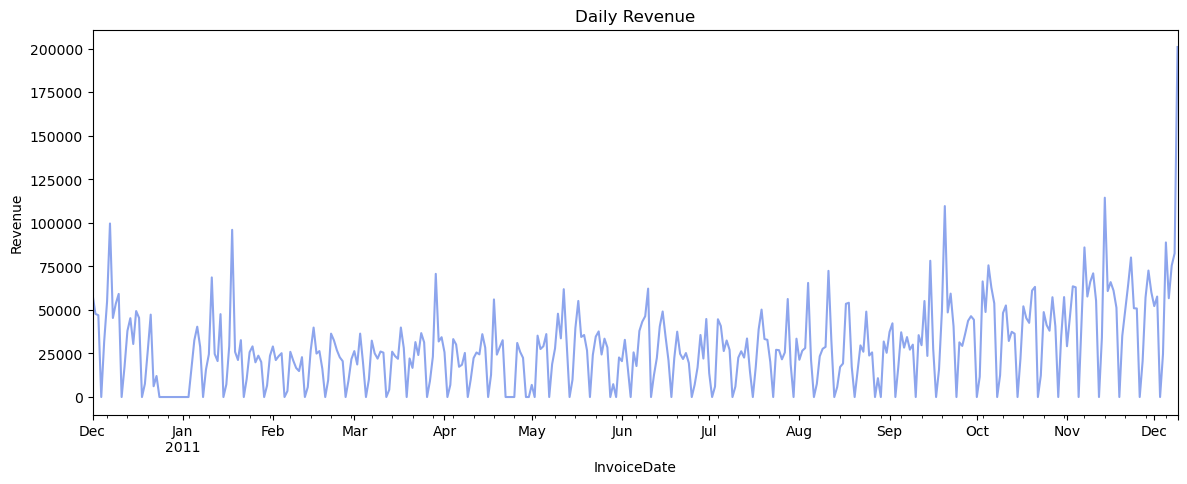

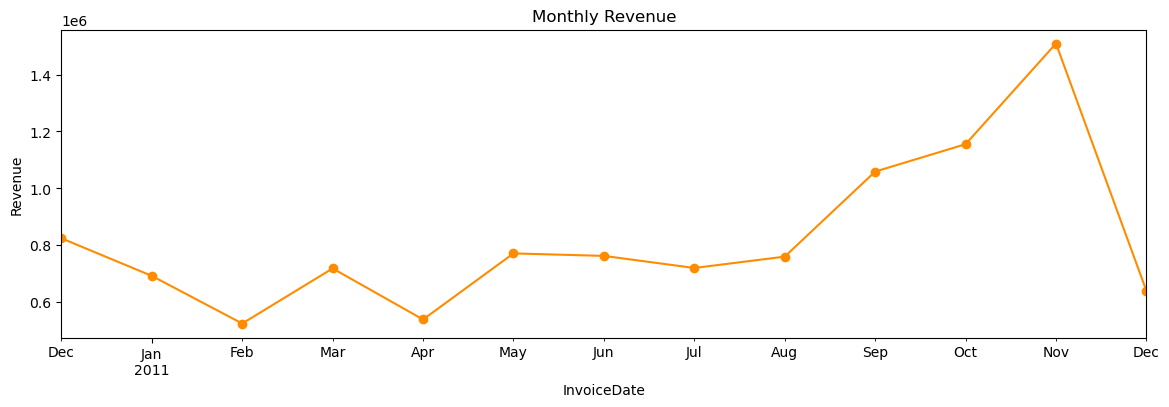

In [10]:
# Generate daily and monthly sales summaries
daily_sales = df_clean.set_index('InvoiceDate')['TotalSales'].resample('D').sum()
monthly_sales = df_clean.set_index('InvoiceDate')['TotalSales'].resample('M').sum()

# Plot trends
plt.figure(figsize=(14, 5))
daily_sales.plot(title='Daily Revenue', color='royalblue', alpha=0.6)
plt.ylabel('Revenue')
plt.show()

plt.figure(figsize=(14, 4))
monthly_sales.plot(title='Monthly Revenue', color='darkorange', marker='o')
plt.ylabel('Revenue')
plt.show()


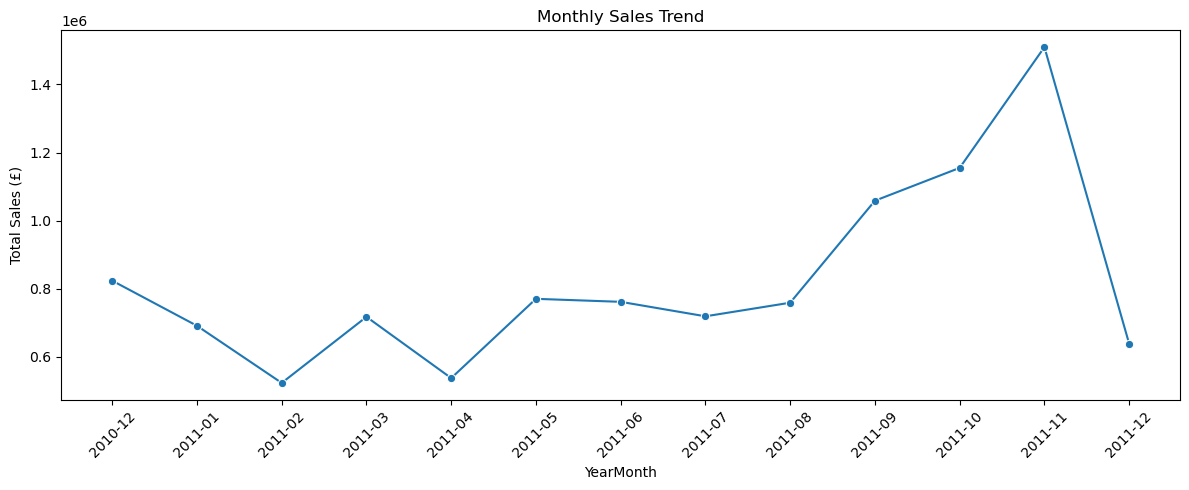

In [11]:
# Extract month and year for grouping
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Aggregate total monthly revenue
monthly_sales = (
    df_clean.groupby('YearMonth')['TotalSales']
    .sum()
    .reset_index()
)
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# Visualize
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='YearMonth', y='TotalSales', marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We observe significant fluctuations in monthly sales:

- Revenue peaked in **November 2011** at approximately **£1.5M**
- The lowest point occurred in **February 2011**, with revenue appearing to fall below **£600K**
- A consistent increase is seen from **August to November 2011**
- **December 2011** shows a sharp decline, which may warrant further investigation to determine if it reflects an actual drop or incomplete data

### 2.2 Weekday Sales Pattern

We analyze how revenue varies by day of the week to identify purchasing habits across weekdays. This helps us detect whether customers tend to order more on specific days, possibly aligned with marketing cycles or operational schedules.

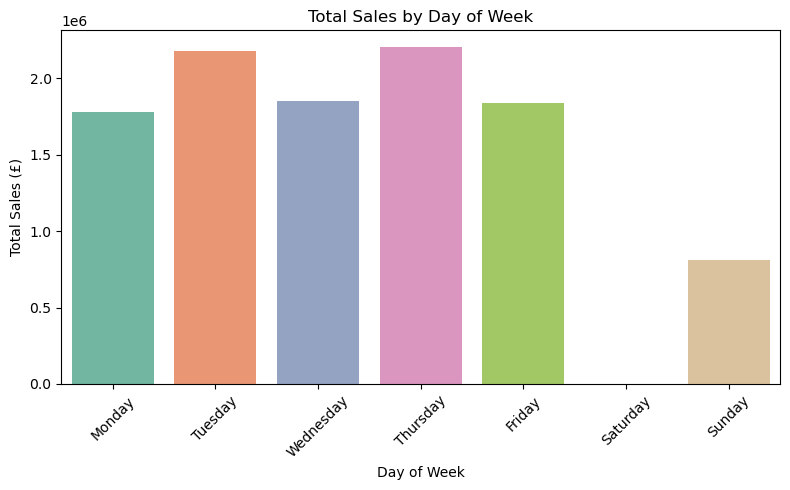

In [12]:
# Extract day of week as string (e.g., 'Monday')
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

# Aggregate revenue by day of week
weekday_sales = (
    df_clean.groupby('DayOfWeek')['TotalSales']
    .sum()
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])  # logical order
    .reset_index()
)
# Define custom color palette (Set2)
colors = sns.color_palette("Set2", len(weekday_sales))

# Visualize
plt.figure(figsize=(8, 5))
sns.barplot(data=weekday_sales, x='DayOfWeek', y='TotalSales', palette=colors)
plt.title('Total Sales by Day of Week')
plt.ylabel('Total Sales (£)')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- **Thursday** recorded the highest total sales, slightly exceeding **£2.2M**
- **Tuesday** also shows strong performance, nearly matching Thursday
- **Sunday** shows the lowest sales, significantly below **£1M**
- **Saturday** appears to have no data, possibly due to no recorded transactions on that day

### 2.3 Hourly Sales Pattern

We analyze how revenue is distributed across different hours of the day to identify time windows when customers are most actively purchasing. This helps detect operational and behavioral trends.

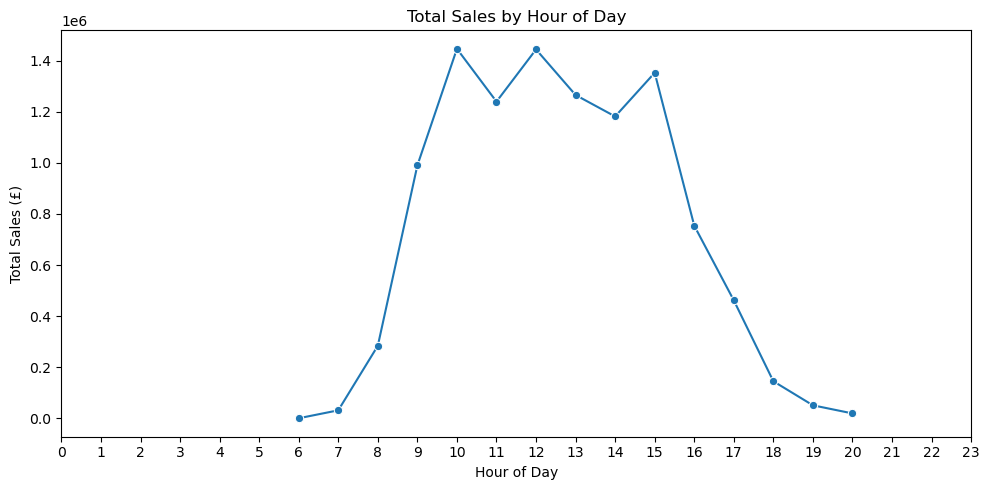

In [13]:
# Extract hour from InvoiceDate
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# Aggregate total revenue by hour
hourly_sales = (
    df_clean.groupby('Hour')['TotalSales']
    .sum()
    .reset_index()
)

# Visualize
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_sales, x='Hour', y='TotalSales', marker='o')
plt.title('Total Sales by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales (£)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

- **Peak activity occurs between 10 AM and 3 PM**, with the highest sales recorded at **10 AM** (over £1.4M)
- A noticeable drop-off begins after **3 PM**, with revenue steadily decreasing into the evening
- Very limited transactions are recorded before **6 AM** or after **8 PM**

### 2.4  Country-wise Sales Distribution

We analyze which countries contribute the most to total revenue. This helps understand geographical distribution and highlights the dominant regions for this e-commerce business.

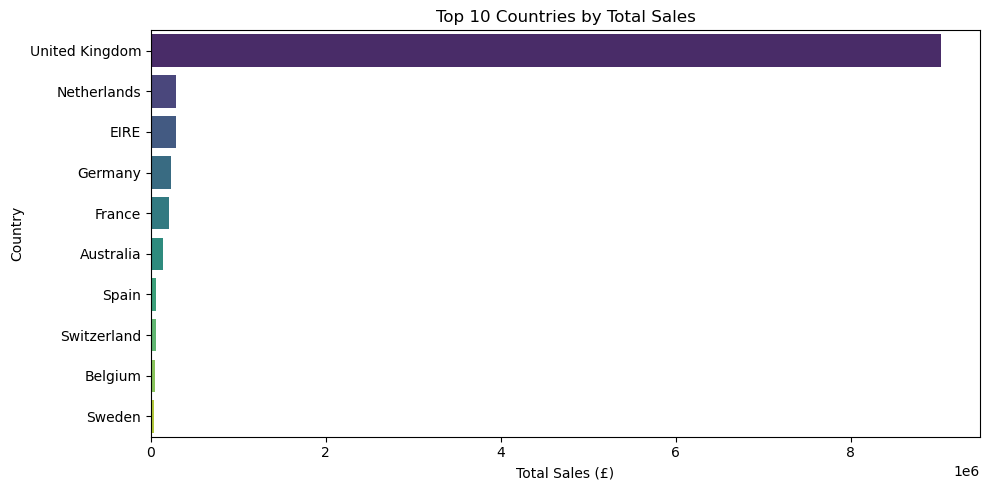

In [14]:
# Aggregate total revenue by country
country_sales = (
    df_clean.groupby('Country')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Visualize top 10 countries
top_10_countries = country_sales.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_countries, x='TotalSales', y='Country', palette='viridis')
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Total Sales (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

- **United Kingdom** overwhelmingly dominates with total sales close to **£9M**
- The next highest contributors—**Netherlands**, **EIRE**, and **Germany**—each account for a significantly smaller share, staying well below **£1M**
- Remaining countries show relatively minor contributions by comparison

### 2.5 Sales by Country

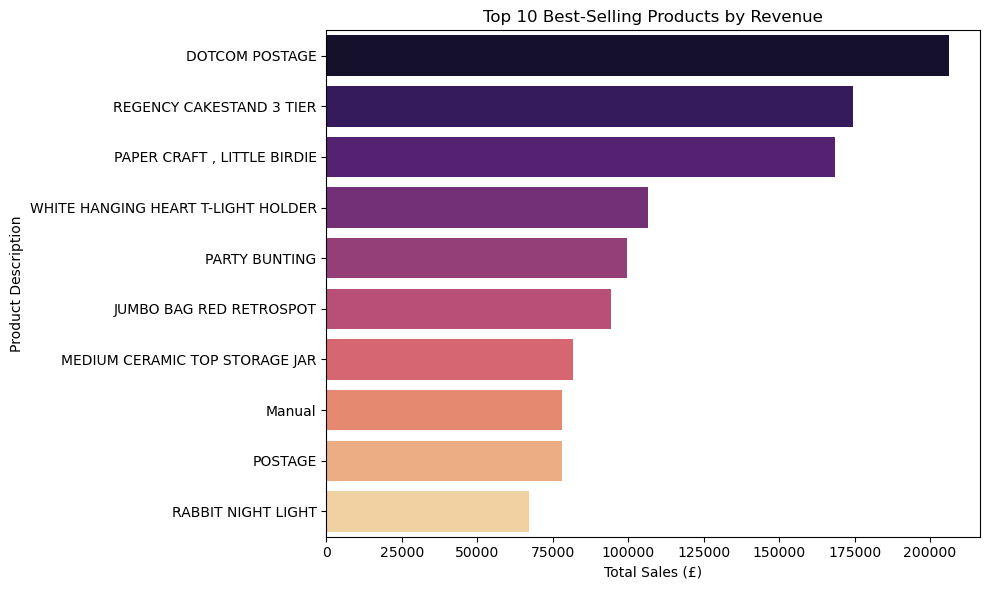

In [15]:
# Aggregate revenue by product description
top_products = (
    df_clean.groupby('Description')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='TotalSales', y='Description', palette='magma')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.xlabel('Total Sales (£)')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

- **DOTCOM POSTAGE** generated the highest revenue, exceeding **£200,000**
- **REGENCY CAKESTAND 3 TIER** and **PAPER CRAFT, LITTLE BIRDIE** followed closely, both surpassing **£170,000**
- Other top contributors include **WHITE HANGING HEART T-LIGHT HOLDER** and **PARTY BUNTING**, each generating between **£100,000–£110,000**
- Functional or logistic items such as **POSTAGE** and **Manual** also appear in the top 10 by total sales

## 3. Feature Engineering

We create new variables based on the transaction data to support:
- downstream customer segmentation
- product grouping
- potential predictive modeling

These features capture time-based behavior, transaction magnitude, and structural patterns.

### 3.1 Time-Based Features

Extract temporal features from the `InvoiceDate` to allow grouping and behavioral profiling by time dimension (e.g., weekday, hour, month).

In [16]:
# Make a copy to avoid chained assignment warnings
df_fe = df_clean.copy()

# Extract temporal features
df_fe['InvoiceYear'] = df_fe['InvoiceDate'].dt.year
df_fe['InvoiceMonth'] = df_fe['InvoiceDate'].dt.month
df_fe['InvoiceDay'] = df_fe['InvoiceDate'].dt.day
df_fe['DayOfWeek'] = df_fe['InvoiceDate'].dt.day_name()
df_fe['Hour'] = df_fe['InvoiceDate'].dt.hour

# Binary features for typical peak hours and weekends
df_fe['IsPeakHour'] = df_fe['Hour'].between(10, 15)
df_fe['IsWeekend'] = df_fe['DayOfWeek'].isin(['Saturday', 'Sunday'])

Multiple features were created based on the `InvoiceDate` column:

- `InvoiceYear`, `InvoiceMonth`, `InvoiceDay`, `Hour`, and `DayOfWeek` capture the basic time components
- `IsPeakHour` flags transactions during the business peak hours (10 AM to 3 PM)
- `IsWeekend` identifies weekend transactions

### 3.2 Transactional Features

We engineer features that describe **the scale and behavior of individual transactions**. These will be especially useful for customer-level aggregation, clustering, or classification later on.

In [17]:
# Number of items per invoice line (already exists as Quantity)
# TotalSales also already exists

# Add average unit price per line (for potential grouping later)
df_fe['UnitRevenue'] = df_fe['TotalSales'] / df_fe['Quantity']

# Flag for bulk order (arbitrary threshold: 50+ units)
df_fe['IsBulk'] = df_fe['Quantity'] >= 50

Features that capture the scale and unit economics of each transaction:

- `UnitRevenue`: average revenue per unit for each invoice line
- `IsBulk`: flags bulk orders (quantity ≥ 50) for identifying high-volume transactions

### 3.3 Aggregated Features by Customer

We generate customer-level features by aggregating transactional data. This enables us to evaluate customer behavior and prepare for segmentation or modeling (e.g., RFM analysis, clustering).

In [18]:
# Filter out guest transactions for customer-level features
df_cust = df_fe[df_fe['CustomerID'] != 'GUEST'].copy()

# Aggregate by CustomerID
customer_features = df_cust.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',                  # Frequency: number of distinct purchases
    'Quantity': 'sum',                       # Total quantity bought
    'TotalSales': 'sum',                     # Monetary: total spending
    'InvoiceDate': ['min', 'max'],           # For Recency calculation
})

# Flatten multi-level columns
customer_features.columns = [
    'NumInvoices', 'TotalQuantity', 'TotalSpent', 'FirstPurchase', 'LastPurchase'
]

# Recency: days since last purchase from max date
latest_date = df_cust['InvoiceDate'].max()
customer_features['RecencyDays'] = (latest_date - customer_features['LastPurchase']).dt.days


Aggregated features were generated at the customer level:

- `NumInvoices`: number of unique purchases
- `TotalQuantity`: total items purchased
- `TotalSpent`: total monetary contribution
- `FirstPurchase`, `LastPurchase`: purchase date range
- `RecencyDays`: number of days since the last purchase

## 4. Customer Segmentation

### 4.1 RFM Analysis

Segment customers based on how recently, how often, and how much they purchased. RFM is widely used in marketing to identify valuable customer segments for retention, reactivation, or targeting campaigns.

#### 4.1.1 Create RFM Table and Scoring

In [19]:
# Copy from previously aggregated customer features
rfm = customer_features[['RecencyDays', 'NumInvoices', 'TotalSpent']].copy()

# Rename columns to R, F, M
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# R score: lower recency is better → reverse scoring
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)

# F and M score: higher is better
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)

# Combine into single RFM score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

#### 4.1.2 RFM Segment Mapping

In [20]:
# Define RFM segment based on simple rules
def map_segment(r, f, m):
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal'
    elif r >= 2 and m >= 3:
        return 'Big Spenders'
    elif r == 4:
        return 'New Customers'
    elif f >= 3:
        return 'Frequent Buyers'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'At Risk'
    else:
        return 'Other'
    
# Apply RFM scoring function
rfm['Segment'] = rfm.apply(
    lambda x: map_segment(int(x['R_score']), int(x['F_score']), int(x['M_score'])),
    axis=1
)
# Define segment names
SEGMENT_NAME_MAP = {
    'Champions': 'Best',
    'Loyal': 'Recent',
    'Big Spenders': 'High-Spend',
    'New Customers': 'New',
    'Frequent Buyers': 'Frequent',
    'At Risk': 'Inactive',
    'Others': 'Other'
}

# Apply segment mapping
rfm['Segment'] = rfm['Segment'].map(SEGMENT_NAME_MAP)

Based on Recency, Frequency, and Monetary scoring, the customer base was segmented into distinct behavioral groups:

| Segment                       | Description                             |
|-------------------------------|-----------------------------------------|
| **Champions (Best)**          | Frequent, recent, and high-value buyers |
| **Loyal (Recent)**            | Purchased recently but with low value   |
| **Big Spenders (High-Spend)** | High spenders with less frequent visits |
| **Frequent Buyers (Frequent)**| Regular buyers with small transactions  |
| **New Customers (New)**       | First-time or very recent customers     |
| **At Risk (Inactive)**        | Long since last purchase, low activity  |
| **Others (Other)**            | No strong behavior pattern              |

#### 4.1.3 RFM Segment Visualization

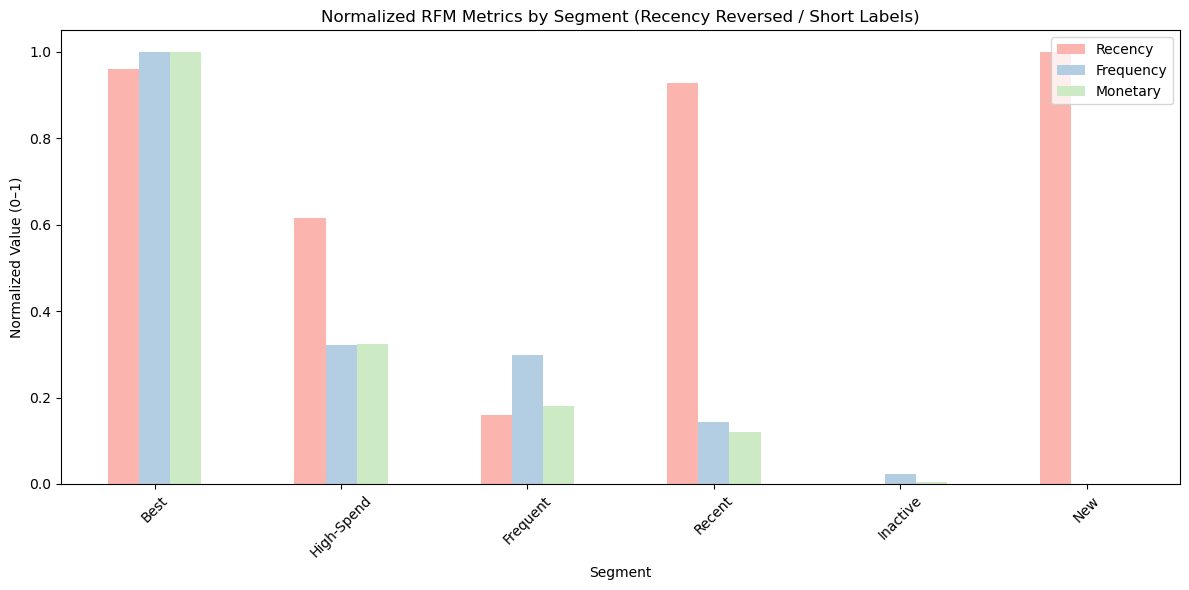

In [21]:
# Calculate average R, F, M per segment
rfm_segment_stats = (
    rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .round(1)
    .sort_values(by='Monetary', ascending=False)
)

# Reverse Recency so that "recent = higher score"
rfm_segment_stats_adj = rfm_segment_stats.copy()
rfm_segment_stats_adj['Recency'] = (
    rfm_segment_stats_adj['Recency'].max() - rfm_segment_stats_adj['Recency']
)

# Normalize all values to [0, 1] scale
rfm_norm_fixed = (
    (rfm_segment_stats_adj - rfm_segment_stats_adj.min()) /
    (rfm_segment_stats_adj.max() - rfm_segment_stats_adj.min())
)

# Visualize normalized RFM
sns.set_palette("Pastel1")
rfm_norm_fixed.plot(kind='bar', figsize=(12, 6))
plt.title('Normalized RFM Metrics by Segment (Recency Reversed / Short Labels)')
plt.ylabel('Normalized Value (0–1)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Using Min–Max normalization with reversed Recency values, we observe the following:

- **Best** clearly score highest across all three metrics:  
  - They purchased recently, made frequent purchases, and generated high revenue.
- **High-Spend** show strong Monetary value but lower Frequency and slightly older Recency.
- **Frequent** exhibit higher Frequency with low Monetary, indicating regular but low-value transactions.
- **Recent** customers purchased recently but in smaller volume and value.
- **Inactive** and **New Customers** have the lowest scores overall — either inactive or not yet engaged.
- **Other** fall between the main strategic groups without distinct RFM characteristics.


### 4.2 K-Means Clustering

We apply unsupervised learning (K-Means) to uncover latent customer groups based on behavioral patterns, without relying on predefined RFM thresholds. This helps discover patterns RFM may miss.

#### 4.2.1 Select and Standardize Features

K-Means is sensitive to feature scale, so all variables need to be standardized. We use `Recency`, `Frequency`, and `Monetary` values as input.

In [22]:
from sklearn.preprocessing import StandardScaler

# Use same customer_features table from earlier
kmeans_data = customer_features[['RecencyDays', 'NumInvoices', 'TotalSpent']].copy()
kmeans_data.columns = ['Recency', 'Frequency', 'Monetary']  # rename for consistency

# Standardize features
scaler = StandardScaler()
kmeans_scaled = scaler.fit_transform(kmeans_data)

#### 4.2.2 Find Optimal K using Elbow Method

We determine the ideal number of clusters (K) by evaluating how inertia (within-cluster sum of squares) changes with increasing K.

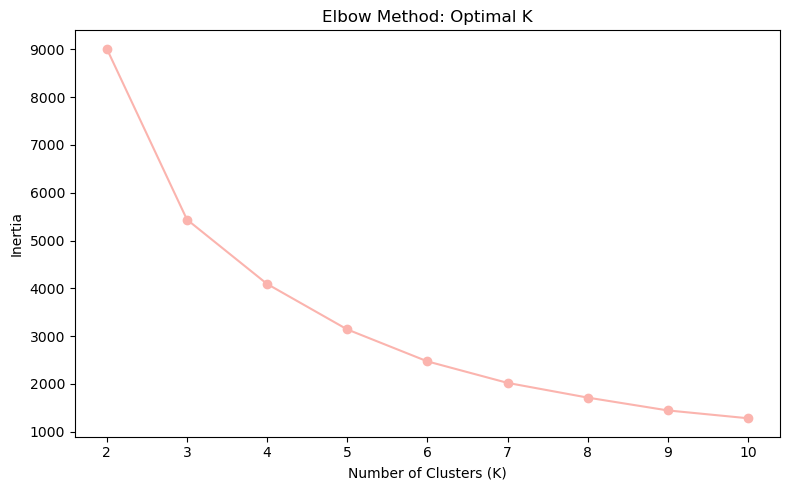

In [23]:
from sklearn.cluster import KMeans

# Try different K values and store inertia
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(kmeans_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method: Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

#### 4.2.3 Apply K-Means with K=4

Based on the elbow method (Step 4.2.2), we selected **K=4** as the optimal number of clusters. We then applied the K-Means algorithm using standardized RFM features to assign each customer to one of four behavior-based clusters.

- Standardized features: `Recency`, `Frequency`, `Monetary`
- Random seed: 42 for reproducibility
- Cluster labels were added back to the original customer-level data

In [24]:
# Apply KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(kmeans_scaled)

# Attach cluster labels to original customer data
kmeans_data_with_labels = kmeans_data.copy()
kmeans_data_with_labels['Cluster'] = kmeans_labels

#### 4.2.4 Visualize Cluster Characteristics

To interpret the behavioral differences among clusters, we calculated the **average RFM metrics per cluster**, applied Min–Max normalization, and plotted them as grouped bar charts.

- This reveals how clusters differ in spending, purchase frequency, and recency.
- Visualization enables intuitive comparison and supports later business recommendations.

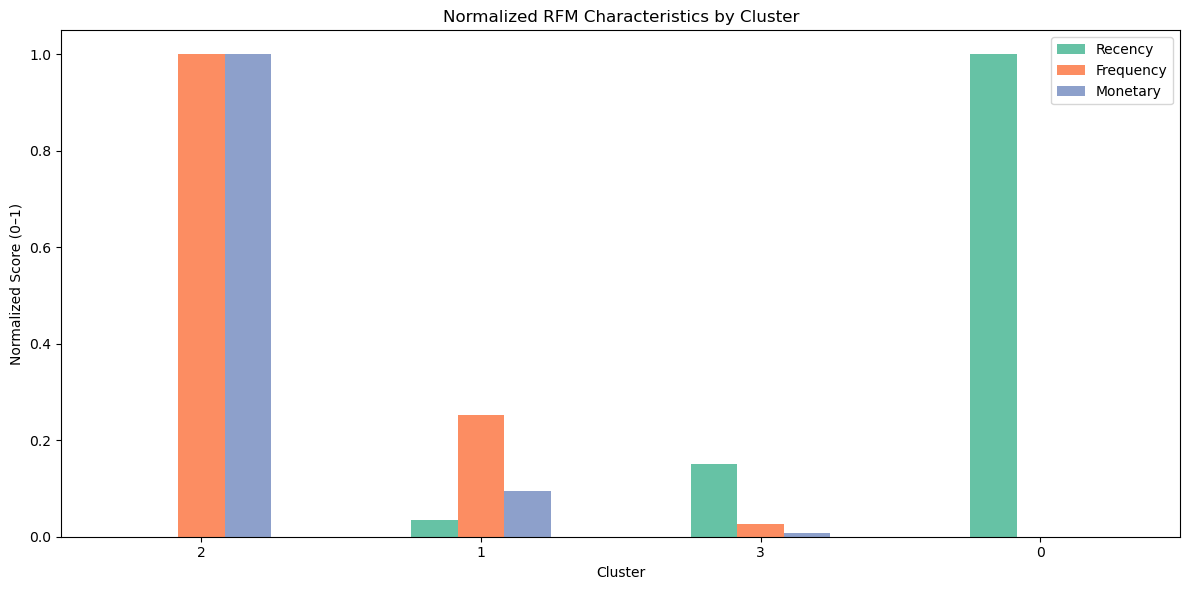

In [25]:
# Aggregate mean RFM per cluster
cluster_summary = (
    kmeans_data_with_labels.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .round(1)
    .sort_values(by='Monetary', ascending=False)
)

# Normalize for comparison
cluster_norm = (
    (cluster_summary - cluster_summary.min()) /
    (cluster_summary.max() - cluster_summary.min())
)

# Visualize
sns.set_palette("Set2")
cluster_norm.plot(kind='bar', figsize=(12, 6))
plt.title('Normalized RFM Characteristics by Cluster')
plt.ylabel('Normalized Score (0–1)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 4.2.6 Visualize Cluster Scatterplot

This scatterplot visualizes the four K-Means customer clusters along two business-critical dimensions:

- **X-axis:** Recency (days since last purchase) → lower = more recent
- **Y-axis:** Total Monetary Value (£)
- **Point Size:** Purchase Frequency
- **Color:** Assigned cluster label

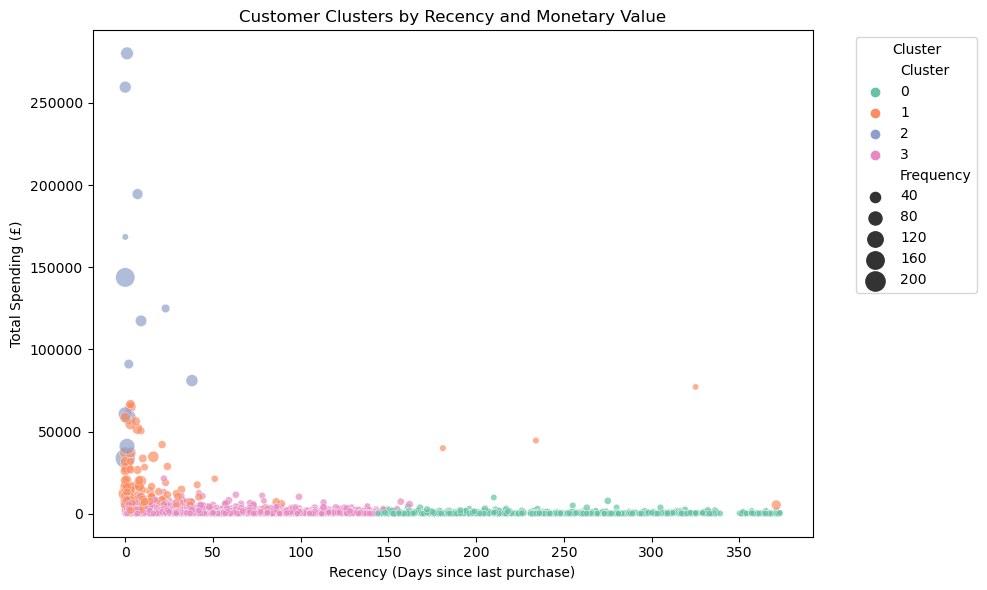

In [26]:
# Attach cluster labels to unscaled customer data
kmeans_plot_df = kmeans_data.copy()
kmeans_plot_df['Cluster'] = kmeans_labels

# Plot: Recency vs Monetary, colored by cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=kmeans_plot_df,
    x='Recency', y='Monetary',
    hue='Cluster', palette='Set2',
    size='Frequency', sizes=(20, 200), alpha=0.7
)
plt.title('Customer Clusters by Recency and Monetary Value')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Total Spending (£)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Each cluster displays distinct customer behaviors based on Recency, Frequency, and Monetary metrics:

| Cluster | Profile Summary |
|---------|------------------|
| **Cluster 2** | High frequency, high spend, and recent activity → **Highly engaged top-value customers** |
| **Cluster 1** | Moderate frequency and spending, relatively recent → **Steady, mid-tier customers** |
| **Cluster 3** | Low frequency and value, moderately recent → **occasional low-spenders** |
| **Cluster 0** | No recent activity, near-zero frequency and spend → **Inactive or churned customers** |



## 5. Summary of Insights

### 🔹 Monthly Sales Trends
- Monthly sales peaked in **November 2011**, with a sharp increase starting from **August**
- **February** marked the lowest month in total sales, followed by a steady rise
- **December** showed a sharp decline, possibly due to limited data recording

### 🔹 Weekday and Hourly Behavior
- **Thursday** and **Tuesday** were the highest revenue days
- Sales concentrated between **10 AM – 3 PM**, with minimal activity in early mornings or late evenings

### 🔹 Country-Level Revenue
- The **United Kingdom** contributed the overwhelming majority of revenue (over £8.9M)
- All other countries showed significantly lower sales volume

### 🔹 Top Products
- Revenue was concentrated in a small group of products, led by **DOTCOM POSTAGE**, **REGENCY CAKESTAND**, and **PAPER CRAFT, LITTLE BIRDIE**

### 🔹 RFM Segmentation
- The majority of valuable customers fall into the **Best** and **High-Spend** segments
- **Inactive** and **New** groups represent low-engagement or reactivation opportunities
- The **Frequent** group indicates opportunity for cross-selling or bundling

### 🔹 K-Means Clustering
- **Cluster 2** = High-value, recent, frequent → likely brand loyalists
- **Cluster 1** = Moderate value, moderately recent → retention candidates
- **Cluster 3** = Low value, mid recency → casual shoppers
- **Cluster 0** = Low value, inactive → reactivation or churned segment

## 6. Actionable Recommendations

| Segment / Cluster | Key Traits | Strategic Action |
|-------------------|------------|------------------|
| **Best (RFM) / Cluster 2** | Recent, frequent, high spend | Implement loyalty rewards, early-access campaigns, premium upselling |
| **High-Spend / Cluster 1** | High spend, lower frequency | Send personalized bundles or promotions to increase visit frequency |
| **Frequent / Cluster 3** | Frequent visits, low value | Promote bulk discounts or cross-sell higher-priced items |
| **Recent / New** | Recent buyers with low engagement | Offer welcome campaigns and introductory bundles |
| **Inactive / Cluster 0** | Long inactivity, low spend | Launch win-back offers (e.g., "We Miss You" email + discount) |
| **Other** | No distinct pattern | Monitor passively, apply general engagement nudges |


## 7. Predictive Modeling for Customer Targeting

This step aims to build a machine learning model to identify customers who are likely to become **high-value contributors** to revenue, based on their behavioral features.

### 7.1 Define Target Variable

We define high-value customers as those in the top 25% of total spending (`Monetary`).  
This binary classification allows us to predict which customers are most likely to contribute significant revenue.

In [27]:
# Define high-value customers (top 25%)
threshold = kmeans_data['Monetary'].quantile(0.75)
kmeans_data_with_labels['HighValueTarget'] = (kmeans_data_with_labels['Monetary'] >= threshold).astype(int)

### 7.2 Select Predictive Features

We use two customer behavioral metrics:

- `Recency`: How recently the customer purchased  
- `Frequency`: How often the customer purchased

These were selected based on previous EDA and segmentation insights.

In [28]:
# Select features and target
model_features = kmeans_data_with_labels[['Recency', 'Frequency']]
target = kmeans_data_with_labels['HighValueTarget']

### 7.3 Handle Class Imbalance

The dataset shows a 75:25 class imbalance.  
To compensate, we compute `scale_pos_weight = 3.0`, which adjusts the learning objective to give more weight to underrepresented class 1 (high-value customers).

In [29]:
# Check imbalance ratio
scale_ratio = (target == 0).sum() / (target == 1).sum()
print(f"Scale pos weight: {scale_ratio:.2f}")

Scale pos weight: 3.00


### 7.4 Train-Test Split

We split the data into training and testing sets to evaluate model generalization.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    model_features, target, test_size=0.3, random_state=42
)

### 7.5 Train LightGBM Model

We use LightGBM with `scale_pos_weight` to handle class imbalance.  
This model is chosen for its speed, recall performance, and strong real-world application in classification problems.

In [31]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(scale_pos_weight=scale_ratio, random_state=42)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 755, number of negative: 2281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 268
[LightGBM] [Info] Number of data points in the train set: 3036, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.248682 -> initscore=-1.105651
[LightGBM] [Info] Start training from score -1.105651


LGBMClassifier(random_state=42, scale_pos_weight=2.9981566820276497)

### 7.6 Evaluate Model Performance

We evaluate the model using precision, recall, and F1-score.  
Our primary goal is **high recall for class 1** (high-value customers), ensuring we do not miss key opportunities.

In [32]:
from sklearn.metrics import classification_report

y_pred = lgbm.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       972
           1       0.68      0.78      0.73       330

    accuracy                           0.85      1302
   macro avg       0.80      0.83      0.81      1302
weighted avg       0.86      0.85      0.86      1302



## 8. Advanced Feature Engineering for Model Enhancement

To enhance model accuracy and better capture purchasing behaviors, we introduced features beyond the traditional RFM metrics. These new features reflect pricing sensitivity, purchase timing, and product diversity—factors that are often strong indicators of customer value but are not captured by Recency, Frequency, or Monetary alone.

### 8.1 Create Engineered Features per Customer

We generated individual-level features based on behavioral patterns:

- `IsWeekend`, `IsPeakHour`: Capture temporal behaviors
- `IsBulk`, `AvgUnitPrice`: Capture volume and price sensitivity
- `UniqueProducts`, `DiversityRatio`: Capture product exploration
- `AOV`: Highlights purchase efficiency

These features were first derived at the **transaction level**, then aggregated per customer in the next step.

In [33]:
df_model = df_fe.copy()

# Add derived fields
df_model['TotalSales'] = df_model['Quantity'] * df_model['UnitPrice']
df_model['AvgUnitPrice'] = df_model['TotalSales'] / df_model['Quantity']
df_model['IsBulk'] = df_model['Quantity'] >= 50
df_model['IsWeekend'] = df_model['DayOfWeek'].isin(['Saturday', 'Sunday'])
df_model['IsPeakHour'] = df_model['Hour'].between(10, 15)
df_model['InvoiceDate'] = pd.to_datetime(df_model['InvoiceDate'])

# Compute Recency
latest_date = df_model['InvoiceDate'].max()
df_model['RecencyDays'] = (latest_date - df_model['InvoiceDate']).dt.days

# Remove guest users
df_model = df_model[df_model['CustomerID'] != 'GUEST']


### 8.2 Aggregate Features per Customer

Customer-level aggregation was performed to produce a single row per customer.
We applied logical aggregation strategies for each feature type:

- **Count-based**: `Frequency`, `UniqueProducts`
- **Ratio-based**: `DiversityRatio`, `AOV`
- **Max/mean**: `IsBulk`, `IsWeekend`, `AvgUnitPrice`

This structure enables fair comparison between customers and prepares the data for classification modeling.

In [34]:
agg_df = df_model.groupby('CustomerID').agg({
    'RecencyDays': 'min',
    'InvoiceNo': 'nunique',
    'TotalSales': 'sum',
    'AvgUnitPrice': 'mean',
    'IsBulk': 'max',
    'IsWeekend': 'max',
    'IsPeakHour': 'max',
    'StockCode': 'nunique',
    'Description': 'count'
}).reset_index()

# Rename columns
agg_df.rename(columns={
    'RecencyDays': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSales': 'Monetary',
    'StockCode': 'UniqueProducts',
    'Description': 'TotalItems'
}, inplace=True)

# Create new feature: Diversity ratio (unique products per order)
agg_df['DiversityRatio'] = agg_df['UniqueProducts'] / agg_df['Frequency']

# Create AOV: Average Order Value
agg_df['AOV'] = agg_df['Monetary'] / agg_df['Frequency']


### 8.3 Define Target and Train Model

We defined **high-value customers** as those in the **top 25% of monetary value** and labeled them as Class 1.

The LightGBM classifier was trained with class imbalance adjustment using `scale_pos_weight`

In [35]:
# Define X and y
X_eng = agg_df.drop(columns=['CustomerID', 'Monetary', 'AOV'])
y_eng = (agg_df['Monetary'] >= agg_df['Monetary'].quantile(0.75)).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_eng, y_eng, test_size=0.3, random_state=42)

# Compute class imbalance weight
scale_ratio_eng = (y_train == 0).sum() / (y_train == 1).sum()

# Train LightGBM
lgbm_eng = LGBMClassifier(scale_pos_weight=scale_ratio_eng, random_state=42)
lgbm_eng.fit(X_train, y_train)

# Evaluate
y_pred_eng = lgbm_eng.predict(X_test)
print(classification_report(y_test, y_pred_eng))

[LightGBM] [Info] Number of positive: 755, number of negative: 2281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 3036, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.248682 -> initscore=-1.105651
[LightGBM] [Info] Start training from score -1.105651
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       972
           1       0.78      0.84      0.81       330

    accuracy                           0.90      1302
   macro avg       0.86      0.88      0.87      1302
weighted avg       0.90      0.90      0.90      1302



The model demonstrates strong generalization, with a **recall of 0.84 for high-value customers**, meaning we correctly identified 84% of our top-spending customers. This is critical for targeted retention or loyalty programs.

## 9. Outlier Clipping & SHAP Explainability

Before conducting SHAP-based model interpretation, we applied **IQR-based clipping** to limit the influence of extreme outliers that could distort the SHAP values.

This step improves:

- **Interpretability** (stable SHAP rankings)
- **Model robustness** (prevents overfitting to outliers)
- **Business trust** (stakeholders can relate to insights more clearly)

### 9.1 IQR-Based Clipping

Applied to the following features:

- Recency, Frequency, Monetary
- AvgUnitPrice, UniqueProducts
- DiversityRatio, AOV

Each was clipped to the `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` range, ensuring that most observations stay untouched while extreme outliers are softened.

In [36]:
def iqr_clipping(df, cols, k=1.5):
    df_clipped = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        df_clipped[col] = df[col].clip(lower, upper)
    return df_clipped

# Apply to selected features
clip_cols = ['Recency', 'Frequency', 'Monetary', 'AvgUnitPrice', 'UniqueProducts', 'DiversityRatio', 'AOV']
agg_df_clipped = iqr_clipping(agg_df, cols=clip_cols)

### 9.2 Re-train LightGBM with Clipped Features

After clipping, the model was retrained using the same structure and parameters.

In [37]:
# Define new X and y
X_clipped = agg_df_clipped.drop(columns=['CustomerID', 'Monetary', 'AOV'])  # remove target and derived
y_clipped = (agg_df_clipped['Monetary'] >= agg_df_clipped['Monetary'].quantile(0.75)).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_clipped, y_clipped, test_size=0.3, random_state=42)

# Compute scale_pos_weight
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train new model
lgbm_clip = LGBMClassifier(scale_pos_weight=scale_weight, random_state=42)
lgbm_clip.fit(X_train, y_train)

# Evaluate
y_pred_clip = lgbm_clip.predict(X_test)
print(classification_report(y_test, y_pred_clip))

[LightGBM] [Info] Number of positive: 755, number of negative: 2281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1170
[LightGBM] [Info] Number of data points in the train set: 3036, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.248682 -> initscore=-1.105651
[LightGBM] [Info] Start training from score -1.105651
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       972
           1       0.77      0.82      0.79       330

    accuracy                           0.89      1302
   macro avg       0.85      0.87      0.86      1302
weighted avg       0.89      0.89      0.89      1302



There was a **slight decrease** in performance (~0.01–0.02), but this is acceptable as the benefit lies in improved **stability and explainability**.
The model is now better prepared for SHAP interpretation.

### 9.3 SHAP Explainability

**SHAP (SHapley Additive exPlanations)** values provide a powerful way to interpret complex models like LightGBM by showing **how each feature contributes** to individual predictions.

>Our goal is to understand:
> - "Which features most influence the classification of high-value customers"
> - "Whether the model's decision logic aligns with business intuition"

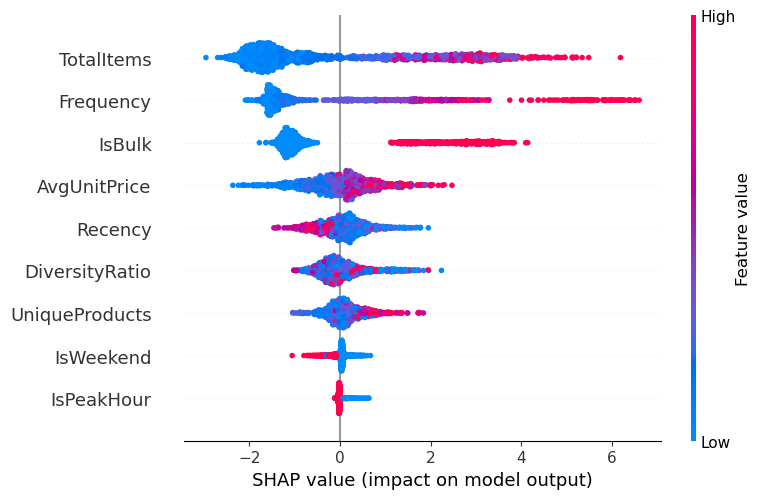

In [38]:
import lightgbm as lgb
import shap

# Create Dataset objects
train_dataset = lgb.Dataset(X_train, label=y_train)
test_dataset = lgb.Dataset(X_test, label=y_test, reference=train_dataset)

params = {
    "objective": "binary",
    "scale_pos_weight": scale_weight,
    "metric": "binary_logloss",
    "verbose": -1,
    "seed": 42
}

lgb_native_model = lgb.train(
    params,
    train_dataset,
    num_boost_round=100,
    valid_sets=[test_dataset]
)

explainer = shap.TreeExplainer(lgb_native_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


Key insights from SHAP analysis:

- **TotalItems** and **Frequency** are the strongest drivers of high-value classification, suggesting that repeat purchase behavior and basket size are critical for customer value.
- **IsBulk** purchasing is a significant indicator, highlighting a subgroup of large-scale buyers.
- Lower **Recency** strongly contributes to high-value predictions, confirming that recent engagement is crucial.
- Features like **AvgUnitPrice**, **DiversityRatio**, and **UniqueProducts** reveal nuanced behavioral patterns that differentiate high-value customers beyond simple RFM measures.
- **Temporal behaviors** (IsWeekend, IsPeakHour) play a smaller but notable role, hinting at possible timing for targeted campaigns.

This insight will guide strategic recommendations for targeted marketing efforts and customer retention programs.


### 9.4 Actionable Recommendation Table

| Segment/Behavior            | Insight from SHAP | Recommended Action |
|-----------------------------|-------------------|--------------------|
| **High TotalItems & High Frequency** | Indicates loyal, frequent buyers with large baskets. | - Loyalty program targeting.<br>- Exclusive previews of new products.<br>- Volume-based discounts. |
| **Bulk Buyers (IsBulk = 1)** | Customers purchasing large quantities at once. | - Special wholesale pricing.<br>- Personalized bulk offers.<br>- Supply chain priority handling. |
| **Low Recency (Recent buyers)** | Recent engagement strongly predicts high value. | - Upsell cross-sell campaigns soon after purchase.<br>- Post-purchase follow-up emails. |
| **High AvgUnitPrice** | Customers buying higher-priced items. | - Premium membership benefits.<br>- Early access to exclusive collections.<br>- Personalized recommendations for luxury goods. |
| **High DiversityRatio & UniqueProducts** | Customers exploring various product categories. | - Bundle promotions across categories.<br>- Personalized discovery emails featuring diverse products.<br>- Engagement via social media showcasing variety. |
| **Weekend & PeakHour shoppers** | Small but notable effect; timing-related buying patterns. | - Timed promotions during peak hours.<br>- Weekend flash sales.<br>- Targeted SMS or push notifications based on shopping time preference. |


### 9.5 ROI Simulation

To translate our machine learning model's predictive power into business terms, we conducted a simple ROI simulation comparing:

- **Without Model Targeting:** Marketing to all customers indiscriminately
- **With Model Targeting:** Marketing only to customers predicted to be high-value by the model

This step bridges the gap between data science and business value, providing stakeholders with tangible financial insights.

In [39]:
# Ground truth labels
true_values = y_test.values

# Model predictions
pred_values = y_pred_clip

# Monetary values for each customer
monetary_values = agg_df_clipped.loc[
    X_test.index, 'Monetary'
].values

# Assumptions for ROI simulation
cost_per_customer = 2         # Marketing cost per customer (£)
expected_uplift = 0.15        # Assumed revenue uplift due to campaign (+15%)

# --- Scenario 1: No targeting (all customers receive marketing) ---

# Total marketing cost
total_cost_all = cost_per_customer * len(true_values)

# Total revenue increase from all customers
total_revenue_all = monetary_values.sum() * (1 + expected_uplift)

# ROI calculation
roi_all = (total_revenue_all - monetary_values.sum() - total_cost_all) / total_cost_all

print(f"ROI without model targeting: {roi_all:.2f}")

# --- Scenario 2: Targeting customers predicted as high-value ---

# Identify customers predicted as high-value
target_indices = np.where(pred_values == 1)[0]

# Total marketing cost for targeted customers
total_cost_model = cost_per_customer * len(target_indices)

# Revenue from targeted customers with assumed uplift
total_revenue_model = monetary_values[target_indices].sum() * (1 + expected_uplift)

# ROI calculation
roi_model = (total_revenue_model - monetary_values[target_indices].sum() - total_cost_model) / total_cost_model

print(f"ROI with model targeting: {roi_model:.2f}")

ROI without model targeting: 87.68
ROI with model targeting: 194.74


- **ROI without model targeting:** ~87.68%
- **ROI with model targeting:** ~194.74%

This simulation shows that using the predictive model to target high-value customers could **more than double the return on investment** compared to blanket marketing. 

Such financial justification strongly supports integrating machine learning into marketing operations, demonstrating not only analytical rigor but also real-world business impact.


## Summary of Insights

This e-commerce analytics project uncovered valuable insights into sales patterns and customer behavior across more than **541,000 transactions**, leading to practical business recommendations and predictive modeling results.

- **Sales Trends**
  - The highest monthly revenue came in **November 2011**, highlighting strong seasonal effects.
  - Sales tended to peak mid-week, especially on Tuesdays and Thursdays, suggesting the best timing for promotions.
  - High-value purchases were mostly made during business hours between 10 AM and 3 PM.

- **Data Cleaning & Standardization**
  - Resolved **220 product code inconsistencies**, ensuring more reliable product-level analysis.
  - Retained around 25% of transactions from guest customers, as these included many top-selling products crucial for revenue insights.

- **Customer Segmentation**
  - RFM and K-Means analysis identified clear high-value segments, characterized by:
    - High purchase frequency and spending spread across diverse products.
    - Low recency, indicating recent engagement and loyal customer behavior.

- **Predictive Modeling**
  - Developed a **LightGBM model** that achieved:
    - **Recall of 0.84** and an **F1-score of 0.81** for identifying high-value customers.
  - SHAP analysis confirmed key drivers such as:
    - **TotalItems**, **Frequency**, and **IsBulk**, all playing significant roles in predicting customer value.

- **Business Impact Simulation**
  - ROI simulations showed that targeting customers predicted as high-value could deliver an impressive **194.74% ROI**, more than doubling returns compared to untargeted campaigns (87.68%).

Overall, this project shows how turning data into insights can drive **real business decisions**, helping e-commerce companies **grow revenue, improve marketing ROI, and build stronger relationships with their customers.**
